Cell 1 Setup

In [1]:
'''!pip install torch torchvision tqdm opencv-python --quiet'''

import os, sys, glob, math, random, numpy as np, cv2, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from pathlib import Path
import torch.amp as amp
from torch import serialization as torch_serialization


Cell 2 Paths and GPU

In [2]:
# --- data paths
BASE_DIR = Path.cwd()
DATA_DIR = Path(os.environ.get('RADAR_DATA_DIR', BASE_DIR / 'P1'))
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Expected radar data folder at {DATA_DIR}. Set RADAR_DATA_DIR if stored elsewhere.")

OUT_DIR = BASE_DIR / "checkpoint"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = str(DATA_DIR)
OUT_DIR = str(OUT_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True
reconstruct = getattr(np.core.multiarray, "_reconstruct", None)
if reconstruct is not None:
    torch_serialization.add_safe_globals([reconstruct])

TORCH_LOAD = torch.load
def load_checkpoint(path, map_location=None, weights_only=False):
    return TORCH_LOAD(path, map_location=map_location, weights_only=weights_only)

_start_method = None
if sys.platform == "win32":
    _start_method = "spawn"

if _start_method is not None:
    try:
        torch.multiprocessing.set_start_method(_start_method, force=True)
    except RuntimeError:
        pass

print("Using device:", device)


Using device: cuda


In [3]:
# --- dataset constants
CAMERA_WIDTH = 640
CAMERA_HEIGHT = 480
LOG_SCALE_INPUT = True


Cell 3 Soft-Argmax and Model

In [4]:
# --- Soft-Argmax
class SoftArgmax2D(nn.Module):
    def __init__(self, beta=1.0):
        super().__init__()
        self.beta = beta
    def forward(self, hms):
        B,K,H,W = hms.shape
        h = torch.softmax(hms.view(B*K, -1) * self.beta, dim=-1).view(B*K,1,H,W)
        xs = torch.linspace(0, W-1, W, device=hms.device).view(1,1,1,W)
        ys = torch.linspace(0, H-1, H, device=hms.device).view(1,1,H,1)
        x = torch.sum(h*xs, dim=[2,3]).view(B,K,1)
        y = torch.sum(h*ys, dim=[2,3]).view(B,K,1)
        coords = torch.cat([x,y], dim=-1)
        conf,_ = torch.max(h.view(B*K,-1), dim=-1)
        return coords, conf.view(B,K)

# --- simple conv backbone
def conv_bn_relu(cin, cout, k=3, s=1, p=1):
    return nn.Sequential(nn.Conv2d(cin, cout, k, s, p, bias=False),
                         nn.BatchNorm2d(cout),
                         nn.ReLU(inplace=True))

class RadarPoseNet(nn.Module):
    def __init__(self, num_kp=17, in_ch=2, base=64, out_res=128):
        super().__init__()
        self.out_res = out_res
        self.backbone = nn.Sequential(
            conv_bn_relu(in_ch, base, 7, 2, 3),
            conv_bn_relu(base, base, 3, 1, 1),
            conv_bn_relu(base, base*2, 3, 2, 1),
            conv_bn_relu(base*2, base*2, 3, 1, 1),
            conv_bn_relu(base*2, base*4, 3, 2, 1),
            conv_bn_relu(base*4, base*4, 3, 1, 1),
            conv_bn_relu(base*4, base*4, 3, 1, 1)
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2), nn.ReLU(True),
            nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base), nn.ReLU(True),
            nn.ConvTranspose2d(base, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base), nn.ReLU(True)
        )
        self.hm_head = nn.Conv2d(base, num_kp, 1)
        self.soft = SoftArgmax2D(beta=10.0)
    def forward(self, x):
        f = self.backbone(x)
        h = self.deconv(f)
        hm = self.hm_head(h)
        coords, conf = self.soft(hm)
        return hm, coords, conf


Cell 4 Dataset loader

In [5]:

def load_radar_frame(root, fid, out_res, log_scale=True):
    with np.load(os.path.join(root, f"{fid}_radar.npz")) as data:
        hm_hori = data["hm_hori"].astype(np.float32)
        hm_vert = data["hm_vert"].astype(np.float32)
    res_hori = cv2.resize(hm_hori, (out_res, out_res), interpolation=cv2.INTER_LINEAR)
    res_vert = cv2.resize(hm_vert, (out_res, out_res), interpolation=cv2.INTER_LINEAR)
    inp = np.stack([res_hori, res_vert], axis=0)
    if log_scale:
        inp = np.log1p(np.clip(inp, a_min=0.0, a_max=None))
    return inp

def compute_channel_stats(root, ids, out_res, cache_path=None, log_scale=True):
    if cache_path and os.path.exists(cache_path):
        cached = np.load(cache_path)
        mean, std = cached["mean"], cached["std"]
        cached.close()
        return mean, std
    sum_c = np.zeros(2, dtype=np.float64)
    sumsq_c = np.zeros(2, dtype=np.float64)
    total_px = 0
    for fid in tqdm(ids, desc="stats", leave=False):
        frame = load_radar_frame(root, fid, out_res, log_scale=log_scale)
        reshaped = frame.reshape(2, -1)
        sum_c += reshaped.sum(axis=1)
        sumsq_c += (reshaped ** 2).sum(axis=1)
        total_px += frame.shape[1] * frame.shape[2]
    denom = max(total_px, 1)
    mean = sum_c / denom
    var = sumsq_c / denom - mean ** 2
    var = np.clip(var, 0.0, None)
    std = np.sqrt(var)
    mean = np.nan_to_num(mean.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    std = np.nan_to_num(std.astype(np.float32), nan=1.0, posinf=1.0, neginf=1.0)
    std = np.maximum(std, 1e-6)
    if cache_path:
        np.savez(cache_path, mean=mean, std=std)
    return mean, std



In [6]:

class RadarPoseDataset(Dataset):
    def __init__(self, data_dir, ids, out_res=128, sigma=2.0, mean=None, std=None, log_scale=True):
        self.root, self.ids, self.out_res, self.sigma = data_dir, ids, out_res, sigma
        self.mean = np.array(mean, dtype=np.float32) if mean is not None else None
        self.std = np.array(std, dtype=np.float32) if std is not None else None
        self.log_scale = log_scale
    def __len__(self): return len(self.ids)
    def _make_heatmaps(self, xy, vis):
        K,H,W = xy.shape[0], self.out_res, self.out_res
        yy,xx = np.meshgrid(np.arange(H),np.arange(W),indexing="ij")
        hms = np.zeros((K,H,W),np.float32)
        for k in range(K):
            if vis[k]<0.5: continue
            x, y = xy[k]
            g=np.exp(-((yy-y)**2+(xx-x)**2)/(2*self.sigma**2))
            hms[k]=g
        return hms
    def __getitem__(self,i):
        fid=self.ids[i]
        inp = load_radar_frame(self.root, fid, self.out_res, log_scale=self.log_scale)
        if self.mean is not None and self.std is not None:
            inp = (inp - self.mean[:, None, None]) / (self.std[:, None, None] + 1e-6)
        else:
            ch_mean = inp.mean(axis=(1,2), keepdims=True)
            ch_std = inp.std(axis=(1,2), keepdims=True) + 1e-6
            inp = (inp - ch_mean) / ch_std
        inp = np.nan_to_num(inp, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

        with np.load(os.path.join(self.root,f"{fid}_pose.npz")) as pose_file:
            pose = pose_file["kp"]
        if pose.ndim == 3:
            kp = pose[0]
        else:
            kp = pose.astype(np.float32)
        xy = kp[:,:2].astype(np.float32)
        vis = (kp[:,2] > 0).astype(np.float32)
        scale_x = self.out_res / float(CAMERA_WIDTH)
        scale_y = self.out_res / float(CAMERA_HEIGHT)
        xy[:,0] *= scale_x
        xy[:,1] *= scale_y
        xy[:,0] = np.clip(xy[:,0], 0.0, self.out_res - 1)
        xy[:,1] = np.clip(xy[:,1], 0.0, self.out_res - 1)
        hms=self._make_heatmaps(xy,vis)
        return {"input":torch.from_numpy(inp),
                "target_hm":torch.from_numpy(hms.astype(np.float32)),
                "target_xy":torch.from_numpy(xy.astype(np.float32)),
                "vis":torch.from_numpy(vis.astype(np.float32)),
                "fid":fid}



Cell 5 Loss + Train/Eval functions

In [7]:
def heatmap_mse(pred,tgt,vis):
    w=vis.view(vis.size(0),vis.size(1),1,1)
    return F.mse_loss(pred*w,tgt*w,reduction="sum")/(w.sum()+1e-6)
def coord_l1(pred,tgt,vis):
    w=vis.unsqueeze(-1)
    return F.l1_loss(pred*w,tgt*w,reduction="sum")/(w.sum()+1e-6)

@torch.no_grad()
def evaluate(model,loader,device):
    model.eval(); tot=0; cnt=0
    for b in loader:
        x=b["input"].to(device, non_blocking=True)
        y=b["target_xy"].to(device, non_blocking=True)
        vis=b["vis"].to(device, non_blocking=True)
        _,p,_=model(x)
        w=vis.unsqueeze(-1)
        tot+=torch.abs((p-y)*w).sum().item()
        cnt+=w.sum().item()
    return tot/(cnt+1e-6)

def train_one_epoch(model,loader,opt,device,lam=0.5,epoch=None,scaler=None,use_amp=False,accum_steps=1):
    model.train(); loss_sum=0.0
    pbar = tqdm(loader, total=len(loader), leave=False, desc=(f"Epoch {epoch:03d} [train]" if epoch is not None else "Train"))
    opt.zero_grad(set_to_none=True)
    step_in_epoch = 0
    for step, b in enumerate(pbar, 1):
        x=b["input"].to(device, non_blocking=True)
        th=b["target_hm"].to(device, non_blocking=True)
        ty=b["target_xy"].to(device, non_blocking=True)
        vis=b["vis"].to(device, non_blocking=True)
        with amp.autocast(device_type="cuda", enabled=use_amp):
            ph,px,_=model(x)
            loss_total = heatmap_mse(ph,th,vis)+lam*coord_l1(px,ty,vis)
        loss_value = float(loss_total.detach())
        loss_sum += loss_value*x.size(0)
        loss = loss_total / max(accum_steps,1)
        if use_amp and scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()
        if step % max(accum_steps,1) == 0:
            if use_amp and scaler is not None:
                scaler.step(opt)
                scaler.update()
            else:
                opt.step()
            opt.zero_grad(set_to_none=True)
        step_in_epoch = step
        pbar.set_postfix(loss=loss_value)
    if step_in_epoch % max(accum_steps,1) != 0:
        if use_amp and scaler is not None:
            scaler.step(opt)
            scaler.update()
        else:
            opt.step()
        opt.zero_grad(set_to_none=True)
    return loss_sum/max(len(loader.dataset),1)



Cell 6 Discover dataset IDs and split

In [8]:
# Recursively discover radar files in nested subfolders
files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_radar.npz"), recursive=True))

# Build IDs as relative paths without the trailing suffix '_radar.npz'
ids = []
for f in files:
    rel = os.path.relpath(f, DATA_DIR)
    if rel.endswith('_radar.npz'):
        ids.append(rel[:-len('_radar.npz')])

random.seed(42)
random.shuffle(ids)

n_total = len(ids)
split_train = int(0.8 * n_total)
split_val = int(0.9 * n_total)

ids_tr = ids[:split_train]
ids_va = ids[split_train:split_val]
ids_te = ids[split_val:]

if len(ids_te) == 0 and len(ids_va) > 0:
    ids_te = ids_va[-1:]
    ids_va = ids_va[:-1]
elif len(ids_te) == 0 and len(ids_tr) > 1:
    ids_te = ids_tr[-1:]
    ids_tr = ids_tr[:-1]

print(f"{len(ids_tr)} train, {len(ids_va)} val, {len(ids_te)} test frames found.")



86321 train, 10790 val, 10791 test frames found.


Cell 7 Dataloaders + Model + Optimizer

In [9]:
BATCH = 128  # tweak per GPU memory; 128 fits comfortably on A40
EPOCHS = 120
LR = 3e-4
OUT_RES = 128
PATIENCE = 15
DEFAULT_WORKERS = int(os.environ.get("RADAR_NUM_WORKERS", 6))
if DEFAULT_WORKERS < 0:
    DEFAULT_WORKERS = 0

available_cpus = os.cpu_count() or DEFAULT_WORKERS or 1
if DEFAULT_WORKERS == 0:
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(DEFAULT_WORKERS, max(1, available_cpus - 2))

MP_CONTEXT = None
if NUM_WORKERS > 0:
    start_method = torch.multiprocessing.get_start_method(allow_none=True)
    if start_method is None:
        start_method = "spawn" if sys.platform == "win32" else "fork"
    if start_method == "spawn" and "ipykernel" in sys.modules:
        print("Spawn start method detected in notebook; forcing DataLoader workers to 0.")
        NUM_WORKERS = 0
    elif start_method != "fork":
        MP_CONTEXT = torch.multiprocessing.get_context(start_method)

ACCUM_STEPS = 1  # increase if you want an effective larger batch without extra memory
USE_AMP = True
RESUME_FROM_LAST = True  # set False to restart even if a checkpoint exists
LAST_CKPT_NAME = "radar_pose_last.pt"
BEST_CKPT_NAME = "radar_pose_best.pt"

stats_cache = os.path.join(OUT_DIR, f"radar_norm_res{OUT_RES}_log{int(LOG_SCALE_INPUT)}.npz")
mean, std = compute_channel_stats(DATA_DIR, ids_tr, OUT_RES, cache_path=stats_cache, log_scale=LOG_SCALE_INPUT)
print(f"Norm stats (mean={mean}, std={std})")

ds_tr = RadarPoseDataset(DATA_DIR, ids_tr, OUT_RES, mean=mean, std=std, log_scale=LOG_SCALE_INPUT)
ds_va = RadarPoseDataset(DATA_DIR, ids_va, OUT_RES, mean=mean, std=std, log_scale=LOG_SCALE_INPUT)
ds_te = RadarPoseDataset(DATA_DIR, ids_te, OUT_RES, mean=mean, std=std, log_scale=LOG_SCALE_INPUT)

loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=True)
if NUM_WORKERS > 0:
    loader_kwargs.update(
        persistent_workers=True,
        prefetch_factor=2,
    )
    if MP_CONTEXT is not None:
        loader_kwargs["multiprocessing_context"] = MP_CONTEXT

dl_tr = DataLoader(ds_tr, BATCH, shuffle=True, **loader_kwargs)
dl_va = DataLoader(ds_va, BATCH, shuffle=False, **loader_kwargs)
dl_te = DataLoader(ds_te, BATCH, shuffle=False, **loader_kwargs)

model = RadarPoseNet(num_kp=17, in_ch=2, base=64, out_res=OUT_RES).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5, min_lr=1e-6)

BEST_CKPT_PATH = os.path.join(OUT_DIR, BEST_CKPT_NAME)
LAST_CKPT_PATH = os.path.join(OUT_DIR, LAST_CKPT_NAME)


Norm stats (mean=[16.963812  0.      ], std=[0.67852956 1.        ])


Cell 8 Training loop

In [10]:
@torch.no_grad()
def _eval_pck(model, loader, device, alpha=0.05):
    model.eval(); correct=0; total=0
    H = W = getattr(model, 'out_res', 128)
    thresh = alpha*max(H, W)
    for b in loader:
        x=b['input'].to(device, non_blocking=True); y=b['target_xy'].to(device, non_blocking=True); vis=b['vis'].to(device, non_blocking=True)
        _,p,_=model(x)
        d=torch.norm((p-y),dim=-1); m=(vis>0.5)
        correct += ((d<thresh)*m).sum().item(); total += m.sum().item()
    return correct/max(total,1)

scaler = amp.GradScaler("cuda", enabled=USE_AMP)
best = float('inf')
no_improve = 0
start_epoch = 1

if RESUME_FROM_LAST and os.path.exists(LAST_CKPT_PATH):
    ckpt = load_checkpoint(LAST_CKPT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    opt.load_state_dict(ckpt['optimizer'])
    sch.load_state_dict(ckpt['scheduler'])
    best = ckpt.get('best_val', best)
    no_improve = ckpt.get('no_improve', 0)
    start_epoch = ckpt.get('epoch', 1)
    scaler_state = ckpt.get('scaler')
    if USE_AMP and scaler_state:
        try:
            scaler.load_state_dict(scaler_state)
        except Exception as exc:
            print(f"Warning: could not load scaler state ({exc}); continuing without AMP state.")
    rng_state = ckpt.get('rng_state')
    if rng_state:
        py_state = rng_state.get('python')
        np_state = rng_state.get('numpy')
        torch_state = rng_state.get('torch')
        cuda_state = rng_state.get('torch_cuda')
        if py_state is not None:
            random.setstate(py_state)
        if np_state is not None:
            np.random.set_state(np_state)
        if torch_state is not None:
            torch.set_rng_state(torch_state.cpu())
        if torch.cuda.is_available() and cuda_state is not None:
            restored_states = []
            if isinstance(cuda_state, torch.Tensor):
                cuda_state = [cuda_state]
            for state in cuda_state:
                if isinstance(state, torch.Tensor):
                    if state.is_cuda:
                        state = state.cpu()
                    if state.dtype is not torch.uint8:
                        state = state.to(torch.uint8)
                else:
                    state = torch.tensor(state, dtype=torch.uint8)
                restored_states.append(state.contiguous())
            try:
                torch.cuda.set_rng_state_all(restored_states)
            except TypeError as exc:
                print(f"Warning: could not restore CUDA RNG state ({exc}); continuing without CUDA RNG state.")
    print(f"Resuming from epoch {start_epoch} with best val {best:.3f} and no_improve={no_improve}")
else:
    if RESUME_FROM_LAST:
        print('No existing last checkpoint. Starting fresh.')
    else:
        print('Resume disabled. Starting fresh.')

for ep in range(start_epoch, EPOCHS+1):
    tr=train_one_epoch(model,dl_tr,opt,device,epoch=ep,scaler=scaler if USE_AMP else None,use_amp=USE_AMP,accum_steps=ACCUM_STEPS)
    val=evaluate(model,dl_va,device)
    val_pck=_eval_pck(model, dl_va, device, alpha=0.05)
    sch.step(val)
    lr=opt.param_groups[0]['lr']
    print(f"Epoch {ep:03d} | lr {lr:.2e} | train {tr:.4f} | val MAE(px) {val:.3f} | PCK@0.05 {val_pck:.3f}")
    if val < best - 1e-3:
        best=val; no_improve=0
        torch.save({'model':model.state_dict(),'out_res':OUT_RES}, BEST_CKPT_PATH)
    else:
        no_improve+=1

    rng_state = {
        'python': random.getstate(),
        'numpy': np.random.get_state(),
        'torch': torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        cuda_states = torch.cuda.get_rng_state_all()
        rng_state['torch_cuda'] = [state.cpu().clone() for state in cuda_states]

    last_payload = {
        'epoch': ep + 1,
        'model': model.state_dict(),
        'optimizer': opt.state_dict(),
        'scheduler': sch.state_dict(),
        'scaler': scaler.state_dict() if USE_AMP else None,
        'best_val': best,
        'no_improve': no_improve,
        'out_res': OUT_RES,
        'rng_state': rng_state,
    }
    torch.save(last_payload, LAST_CKPT_PATH)

    if no_improve>=PATIENCE:
        print(f'Early stopping at epoch {ep} (no improvement {PATIENCE} epochs).')
        break
print('Best val MAE:',best)

if os.path.exists(BEST_CKPT_PATH):
    ckpt = load_checkpoint(BEST_CKPT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    model.eval()
    if len(ids_te) > 0:
        test_mae = evaluate(model, dl_te, device)
        test_pck = _eval_pck(model, dl_te, device, alpha=0.05)
        print(f"Test MAE(px) {test_mae:.3f} | PCK@0.05 {test_pck:.3f}")


No existing last checkpoint. Starting fresh.


Epoch 001 [train]:   0%|          | 0/675 [00:00<?, ?it/s]

Epoch 001 | lr 3.00e-04 | train 107.9353 | val MAE(px) 27.652 | PCK@0.05 0.085


Epoch 002 [train]:   0%|          | 0/675 [00:00<?, ?it/s]

Epoch 002 | lr 3.00e-04 | train 26.0511 | val MAE(px) 26.937 | PCK@0.05 0.091


...

Epoch 060 | lr 9.37e-06 | train 4.7352 | val MAE(px) 5.023 | PCK@0.05 0.846


Epoch 061 [train]:   0%|          | 0/675 [00:00<?, ?it/s]

Epoch 061 | lr 9.37e-06 | train 4.7227 | val MAE(px) 5.044 | PCK@0.05 0.845


Epoch 062 [train]:   0%|          | 0/675 [00:00<?, ?it/s]

Epoch 062 | lr 9.37e-06 | train 4.7132 | val MAE(px) 5.142 | PCK@0.05 0.840
Early stopping at epoch 62 (no improvement 15 epochs).
Best val MAE: 4.876481124201662
Test MAE(px) 4.902 | PCK@0.05 0.846


Cell 9 Quick inference test

In [11]:
if not os.path.exists(BEST_CKPT_PATH):
    raise FileNotFoundError(f'Expected checkpoint at {BEST_CKPT_PATH}. Train the model first.')
ckpt = load_checkpoint(BEST_CKPT_PATH, map_location=device, weights_only=False)

model.load_state_dict(ckpt['model']); model.eval()

sample=ds_va[0]
x=sample['input'].unsqueeze(0).to(device)
_,pred,conf=model(x)
print('Predicted coords (heatmap space):', pred[0].detach().cpu().numpy()[:5])
print('Conf:', conf[0].detach().cpu().numpy()[:5])


Predicted coords (heatmap space): [[90.65873  28.40853 ]
 [90.7717   27.610489]
 [88.00237  27.546963]
 [95.99278  28.007725]
 [86.3723   28.91976 ]]
Conf: [0.9718374  0.90779895 0.7900372  0.9996768  0.54104024]


Cell PCK metric

In [12]:
@torch.no_grad()
def evaluate_pck(model, loader, device, alpha=0.05):
    model.eval(); correct=0; total=0
    H = W = getattr(model, 'out_res', 128)
    thresh = alpha*max(H, W)
    for b in loader:
        x=b['input'].to(device, non_blocking=True)
        y=b['target_xy'].to(device, non_blocking=True)
        vis=b['vis'].to(device, non_blocking=True)
        _,p,_=model(x)
        d=torch.norm((p-y),dim=-1)
        m=(vis>0.5)
        correct += ((d<thresh)*m).sum().item()
        total += m.sum().item()
    return correct/max(total,1)

val_pck = evaluate_pck(model, dl_va, device, alpha=0.05)
print(f'Val PCK@0.05: {val_pck:.3f}')
if len(ids_te) > 0:
    test_pck = evaluate_pck(model, dl_te, device, alpha=0.05)
    print(f'Test PCK@0.05: {test_pck:.3f}')



Val PCK@0.05: 0.848
Test PCK@0.05: 0.846


Cell Prediction visualization

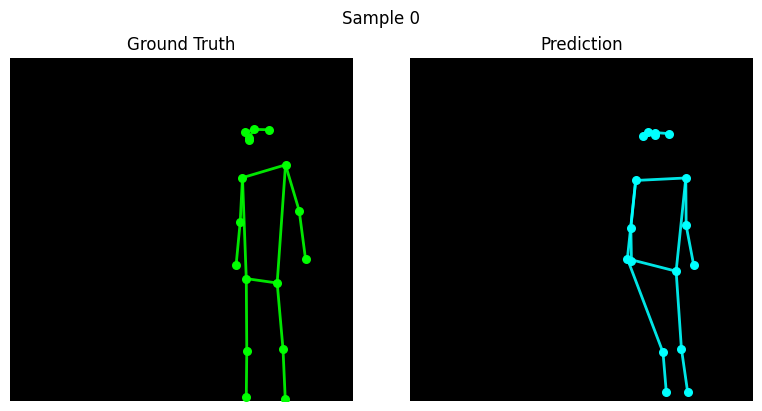

In [13]:

import matplotlib.pyplot as plt
import numpy as np

# Pairs of keypoints to draw the pose skeleton (COCO-style order)
SKELETON_EDGES = [
    (15, 13), (13, 11), (16, 14), (14, 12),
    (11, 12), (5, 11), (6, 12), (5, 6),
    (5, 7), (7, 9), (6, 8), (8, 10),
    (1, 2), (0, 1), (0, 2), (1, 3), (2, 4),
]

def _plot_pose(ax, coords, vis_mask, color, title, hw):
    H, W = hw
    ax.imshow(np.zeros((H, W)), cmap='gray', vmin=0, vmax=1)
    for i, j in SKELETON_EDGES:
        if vis_mask[i] and vis_mask[j]:
            ax.plot([coords[i, 0], coords[j, 0]],
                    [coords[i, 1], coords[j, 1]],
                    color=color, linewidth=2, alpha=0.9)
    ax.scatter(coords[vis_mask, 0], coords[vis_mask, 1], c=color, s=30)
    ax.set_xlim(0, W - 1)
    ax.set_ylim(H - 1, 0)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.axis('off')

def show_sample(sample, idx=0):
    hw = sample['input'].shape[1:]
    x = sample['input'].unsqueeze(0).to(device)
    _, pred, _ = model(x)
    pred = pred[0].detach().cpu().numpy()
    gt = sample['target_xy'].numpy()
    vis = sample['vis'].numpy() > 0.5

    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    _plot_pose(axes[0], gt, vis, color='lime', title='Ground Truth', hw=hw)
    _plot_pose(axes[1], pred, vis, color='cyan', title='Prediction', hw=hw)
    fig.suptitle(f'Sample {idx}')
    plt.show()

show_sample(ds_va[0], idx=0)
